In [4]:
import numpy as np
import mne
from matplotlib import pyplot as plt
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
from tqdm import tqdm
from scipy.signal import hilbert
from sklearn.preprocessing import MinMaxScaler
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
import os

In [2]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_002_preprocessed_combined_py.fif
 file_name: subject_002_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 2
 test_subject_indices: [1,2,13,24,29,34,42,43,52,60,62,67,69,80]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""


def load_config(CFG=CFG_YAML):
    cfg = OmegaConf.create(yaml.safe_load(CFG))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()


def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

In [14]:
data_beta_gamma = mne.read_epochs("../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Beta+Gamma_preprocessed_combined_py.fif")

Reading /home/marco/Documents/GitHub/tms_eeg_decoding/frequency_power_data/../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Beta+Gamma_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/tmp/ipykernel_4921/2097835023.py:1: RuntimeWarning: This filename (../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Beta+Gamma_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  data_beta_gamma = mne.read_epochs("../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Beta+Gamma_preprocessed_combined_py.fif")


Adding metadata with 1 columns
721 matching events found
No baseline correction applied
0 projection items activated


In [47]:
psd, freq = mne.time_frequency.psd_array_multitaper(data_beta_gamma.get_data()[0,7], sfreq=1000,fmax=55)

    Using multitaper spectrum estimation with 7 DPSS windows


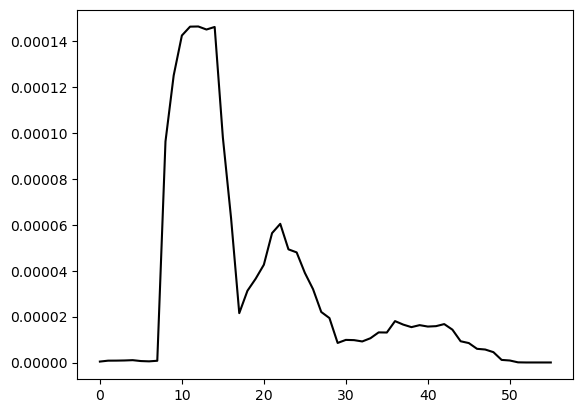

In [48]:
fig = plt.figure()
plt.plot(freq, psd, color='k')

In [50]:
data_alpha_beta_gamma = mne.read_epochs("../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Alpha+Beta+Gamma_preprocessed_combined_py.fif")

Reading /home/marco/Documents/GitHub/tms_eeg_decoding/frequency_power_data/../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Alpha+Beta+Gamma_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/tmp/ipykernel_4921/4289391722.py:1: RuntimeWarning: This filename (../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Alpha+Beta+Gamma_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  data_alpha_beta_gamma = mne.read_epochs("../data/frequency_bandstop/subject_002_bandpass_freq_interaction_Alpha+Beta+Gamma_preprocessed_combined_py.fif")


Adding metadata with 1 columns
721 matching events found
No baseline correction applied
0 projection items activated


    Using multitaper spectrum estimation with 7 DPSS windows


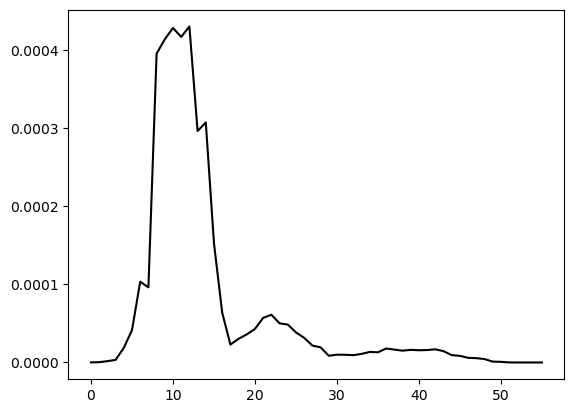

In [51]:
psd, freq = mne.time_frequency.psd_array_multitaper(data_alpha_beta_gamma.get_data()[0,7], sfreq=1000,fmax=55)
fig = plt.figure()
plt.plot(freq, psd, color='k')

In [5]:
cfg = load_config(CFG_YAML)


cfg.exp_name = f"S4_S4EEGNet_ema_100_cal_py_{cfg.dataset.subject_index}"
cli_args = parse_args()
cfg = update_config(cfg, cli_args)
save_config(cfg)
all_epochs, all_labels_raw, fixed_median, fixed_q1, fixed_q3, labels_scaler, mean_mep, ch_names = load_eeg_data(cfg)

wandb:
  key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model: null
dataset:
  data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
  file_name: subject_002_preprocessed_combined_py.fif
  exclude_timepoints: 100
  subject_index: 2
  test_subject_indices:
  - 1
  - 2
  - 13
  - 24
  - 29
  - 34
  - 42
  - 43
  - 52
  - 60
  - 62
  - 67
  - 69
  - 80
training:
  training_start_len: 100
  pretrain_epochs: 100
  pretrain_lr: 0.0001
  val_window_len: 1
  epochs_per_window: 10
  num_warmup_epochs: 5
  num_epochs: 800
  slide_step: 1
  batch_size: 50
  random_seed: 42
  precision: bf16
  kde_lambda: 0.5
  finetune_entire_model: true
exp_name: S4_S4EEGNet_ema_100_cal_py_2_

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/pulse phase eval/data/data_loader.py:38: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
721 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


In [7]:
print(ch_names)

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Iz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Fpz', 'CPz', 'POz', 'Oz']
